In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.375.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.704.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.8597.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.5740.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.5703.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.7717.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.2618.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.1956.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.5608.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.5646.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.7267.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.5341.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.7792.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/dogs/dog.2888.jpg
/kaggle/input/datasets/princelv84/dogsvscats/test/

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    Flatten,
    Dense,
    MaxPooling2D,
    Dropout
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import accuracy_score

In [3]:
train_dir = '/kaggle/input/datasets/princelv84/dogsvscats/train'
test_dir = '/kaggle/input/datasets/princelv84/dogsvscats/test'

In [4]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=20, class_mode='binary')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(224, 224), batch_size=20, class_mode='binary')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

2026-07-14 09:27:23.258081: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,812,865 (18.36 MB)

 Trainable params: 4,812,865 (18.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras import optimizers

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-3),
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 897s 895ms/step - accuracy: 0.6292 - loss: 0.6310 - val_accuracy: 0.6784 - val_loss: 0.6009
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 902s 876ms/step - accuracy: 0.7507 - loss: 0.5095 - val_accuracy: 0.7278 - val_loss: 0.5308
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 883s 883ms/step - accuracy: 0.8160 - loss: 0.4119 - val_accuracy: 0.8402 - val_loss: 0.3731
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 885s 885ms/step - accuracy: 0.8591 - loss: 0.3324 - val_accuracy: 0.8506 - val_loss: 0.3440
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 940s 903ms/step - accuracy: 0.8942 - loss: 0.2594 - val_accuracy: 0.8634 - val_loss: 0.3476
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 878s 878ms/step - accuracy: 0.9197 - loss: 0.1969 - val_accuracy: 0.8834 - val_loss: 0.2992
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 887s 886ms/step - accuracy: 0.9459 - loss: 0.1447 - val_accuracy: 0.8738 - val_loss: 0.3598
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 889s 889ms/step - ac

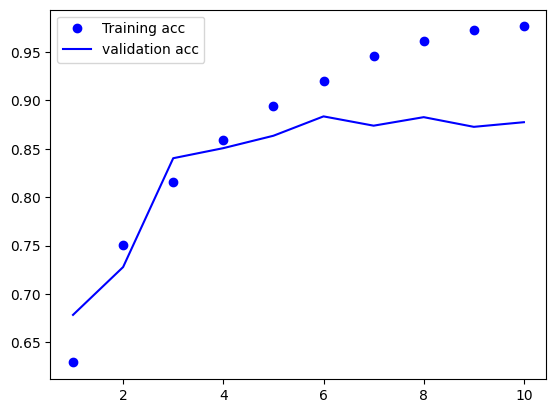

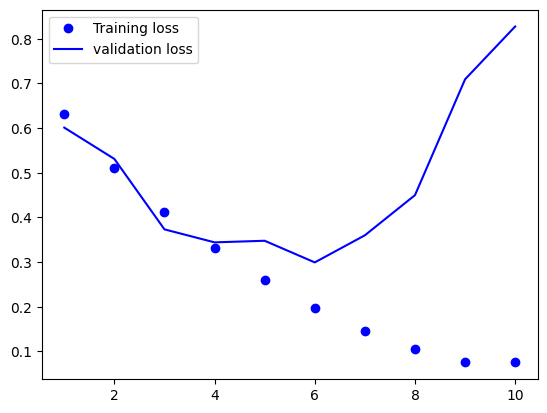

In [9]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs, acc,'bo', label='Training acc')
plt.plot(epochs, val_acc,'b', label='validation acc')
plt.legend()
plt.show()

plt.plot(epochs, loss,'bo', label='Training loss')
plt.plot(epochs, val_loss,'b', label='validation loss')
plt.legend()

plt.show()

In [10]:
model.save("model.keras")

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

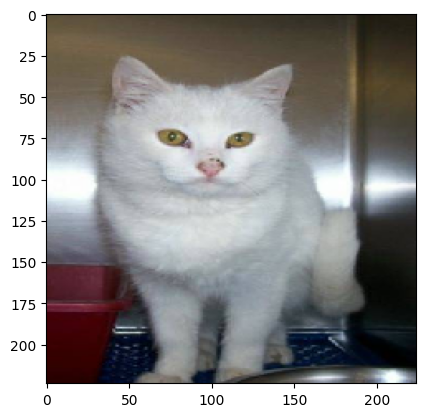

In [12]:
img_path = "/kaggle/input/datasets/princelv84/dogsvscats/test/cats/cat.10052.jpg"

img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.show()

In [13]:
img_array = image.img_to_array(img)
img_array = img_array / 255.0      # Same rescaling used during training
img_array = np.expand_dims(img_array, axis=0)

In [14]:
print(img_array.shape)

(1, 224, 224, 3)


In [15]:
prediction = model.predict(img_array)

print(prediction)
if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
[[1.419165e-27]]
Cat
